# Análisis Exploratorio de Datos (EDA)
## Dataset: `bnf.src_lm_10101_benef_mensual desde 2020 PSEUDONIMIZADOS`

**Objetivo:** Entender el comportamiento del dataset de beneficios mensuales BNF (código 10101) desde 2020, identificando patrones temporales, distribuciones del monto del beneficio, comportamiento por tipo de afiliado y tipo de beneficio, y la concentración de beneficios por afiliado pseudonimizado.

---

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del Dataset

In [2]:
FILE_PATH = 'bnf.src_lm_10101_benef_mensual desde 2020 PSEUDONIMIZADOS.csv'

df = pd.read_csv(
    FILE_PATH,
    sep=';',
    encoding='utf-8-sig',
    low_memory=False
)

print(f'Dataset cargado exitosamente.')
print(f'  Filas:    {df.shape[0]:,}')
print(f'  Columnas: {df.shape[1]}')

Dataset cargado exitosamente.
  Filas:    246,330
  Columnas: 7


## 3. Vista General del Dataset

In [3]:
print('=== Primeras 5 filas ===')
df.head()

=== Primeras 5 filas ===


,Periodo,Version,Tipo_afiliado,Tipo_Beneficio,Monto_Beneficio,Fecha_Otorg_Beneficio,ID_AFI
0,202208,19/08/2024 10:20,2.0000,8,14720,20220816,AFI_00000001
1,202312,19/08/2024 10:31,2.0000,8,34206,20231204,AFI_00000001
2,202506,21/07/2025 10:56,2.0000,8,10704,20250604,AFI_00000001
3,202212,17/01/2023 18:33,2.0000,8,5504,20221229,AFI_00000018
4,202301,27/02/2023 10:01,2.0000,8,12294,20230103,AFI_00000018


In [4]:
print('=== Últimas 5 filas ===')
df.tail()

=== Últimas 5 filas ===


,Periodo,Version,Tipo_afiliado,Tipo_Beneficio,Monto_Beneficio,Fecha_Otorg_Beneficio,ID_AFI
246325,202511,16/12/2025 17:23,10.0000,8,14428,20251119,AFI_01476170
246326,202305,19/06/2023 11:03,2.0000,8,40272,20230505,AFI_01476172
246327,202403,16/04/2024 17:41,2.0000,8,19097,20240301,AFI_01476172
246328,202505,21/07/2025 10:56,2.0000,8,8860,20250528,AFI_01476172
246329,202506,21/07/2025 10:56,2.0000,8,8997,20250625,AFI_01476172


In [5]:
print('=== Tipos de datos y valores no nulos ===')
df.info(verbose=True, show_counts=True)

=== Tipos de datos y valores no nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 246330 entries, 0 to 246329
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Periodo                246330 non-null  int64  
 1   Version                246330 non-null  str    
 2   Tipo_afiliado          246325 non-null  float64
 3   Tipo_Beneficio         246330 non-null  int64  
 4   Monto_Beneficio        246330 non-null  int64  
 5   Fecha_Otorg_Beneficio  246330 non-null  int64  
 6   ID_AFI                 246330 non-null  str    
dtypes: float64(1), int64(4), str(2)
memory usage: 13.2 MB


In [6]:
# Clasificación de columnas por tipo
col_numericas   = df.select_dtypes(include=['number']).columns.tolist()
col_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Columnas numéricas   ({len(col_numericas)}): {col_numericas}')
print(f'Columnas categóricas ({len(col_categoricas)}): {col_categoricas}')

Columnas numéricas   (5): ['Periodo', 'Tipo_afiliado', 'Tipo_Beneficio', 'Monto_Beneficio', 'Fecha_Otorg_Beneficio']
Columnas categóricas (2): ['Version', 'ID_AFI']


## 4. Conversión de Tipos y Enriquecimiento Temporal

In [7]:
# Periodo (YYYYMM) → fecha de período
df['FECHA_PERIODO'] = pd.to_datetime(df['Periodo'].astype(str), format='%Y%m')
df['ANIO']  = df['FECHA_PERIODO'].dt.year
df['MES']   = df['FECHA_PERIODO'].dt.month

# Fecha_Otorg_Beneficio (YYYYMMDD) → fecha de otorgamiento
df['FECHA_OTORG'] = pd.to_datetime(
    df['Fecha_Otorg_Beneficio'].astype(str), format='%Y%m%d', errors='coerce'
)

# Version → timestamp de carga
df['Version_DT'] = pd.to_datetime(df['Version'], dayfirst=True, errors='coerce')

# Tipo_afiliado como categoría
df['Tipo_afiliado'] = df['Tipo_afiliado'].astype('Int64')

print('Conversiones de tipo completadas.')
print(f'  FECHA_PERIODO rango: {df["FECHA_PERIODO"].min().strftime("%Y-%m")} → {df["FECHA_PERIODO"].max().strftime("%Y-%m")}')
print(f'  FECHA_OTORG   rango: {df["FECHA_OTORG"].min().date()} → {df["FECHA_OTORG"].max().date()}')
print(f'  Version_DT    rango: {df["Version_DT"].min()} → {df["Version_DT"].max()}')

Conversiones de tipo completadas.
  FECHA_PERIODO rango: 2022-08 → 2026-02
  FECHA_OTORG   rango: 2022-08-01 → 2026-02-27
  Version_DT    rango: 2022-10-20 10:53:00 → 2026-03-17 11:16:00


## 5. Análisis de Valores Nulos

In [8]:
nulos = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(4)
}).sort_values('Nulos', ascending=False)

print('=== Valores Nulos por Columna ===')
display(nulos)
print(f'\nColumnas sin valores nulos: {(nulos["Nulos"] == 0).sum()} de {len(df.columns)}')

=== Valores Nulos por Columna ===


,Nulos,Porcentaje (%)
Tipo_afiliado,5,0.0020
Periodo,0,0.0000
Version,0,0.0000
Tipo_Beneficio,0,0.0000
Monto_Beneficio,0,0.0000
Fecha_Otorg_Beneficio,0,0.0000
ID_AFI,0,0.0000
FECHA_PERIODO,0,0.0000
ANIO,0,0.0000
MES,0,0.0000



Columnas sin valores nulos: 11 de 12


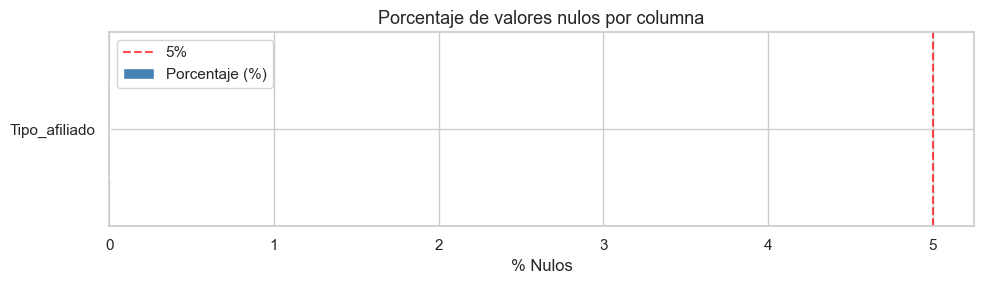

In [9]:
cols_con_nulos = nulos[nulos['Nulos'] > 0].index.tolist()

if cols_con_nulos:
    fig, ax = plt.subplots(figsize=(10, max(3, len(cols_con_nulos) * 0.6)))
    nulos.loc[cols_con_nulos, 'Porcentaje (%)'].sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white'
    )
    ax.set_title('Porcentaje de valores nulos por columna', fontsize=13)
    ax.set_xlabel('% Nulos')
    ax.axvline(5, color='red', linestyle='--', alpha=0.7, label='5%')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No hay valores nulos en las columnas originales.')

## 6. Estadísticas Descriptivas

In [10]:
print('=== Variables Numéricas — Estadísticas Descriptivas ===')
cols_desc = ['Tipo_afiliado', 'Tipo_Beneficio', 'Monto_Beneficio']
df[cols_desc].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', '50%'])

=== Variables Numéricas — Estadísticas Descriptivas ===


,count,mean,std,min,25%,50%,75%,max
Tipo_afiliado,246325.000000,3.509063,2.306530,1.000000,2.000000,2.000000,5.000000,11.000000
Tipo_Beneficio,246330.000000,7.140612,1.934204,1.000000,8.000000,8.000000,8.000000,10.000000
Monto_Beneficio,246330.000000,21316.830727,18686.396655,46.000000,6940.000000,15094.500000,28566.500000,219206.000000


In [11]:
stats_extra = pd.DataFrame({
    'Skewness': df[cols_desc].skew(),
    'Kurtosis': df[cols_desc].kurt(),
    'Ceros': (df[cols_desc] == 0).sum(),
    'Negativos': (df[cols_desc] < 0).sum()
})
print('=== Asimetría, Curtosis, Ceros y Negativos ===')
display(stats_extra)

=== Asimetría, Curtosis, Ceros y Negativos ===


,Skewness,Kurtosis,Ceros,Negativos
Tipo_afiliado,1.6059,1.8936,0,0
Tipo_Beneficio,-1.9873,2.5164,0,0
Monto_Beneficio,1.8745,4.8782,0,0


## 7. Análisis de Duplicados

In [12]:
total_dups = df.duplicated().sum()
print(f'Filas completamente duplicadas: {total_dups:,} ({total_dups/len(df)*100:.4f}%)')

# Verificar si un mismo afiliado puede tener múltiples beneficios del mismo tipo en el mismo período
clave_negocio = ['ID_AFI', 'Periodo', 'Tipo_Beneficio']
dups_negocio = df.duplicated(subset=clave_negocio).sum()
print(f'Duplicados por clave (ID_AFI, Periodo, Tipo_Beneficio): {dups_negocio:,} ({dups_negocio/len(df)*100:.4f}%)')

if dups_negocio > 0:
    print('\nEjemplos de duplicados por clave de negocio:')
    mascara_dup = df.duplicated(subset=clave_negocio, keep=False)
    display(df[mascara_dup].sort_values(clave_negocio).head(10))

Filas completamente duplicadas: 7,258 (2.9465%)
Duplicados por clave (ID_AFI, Periodo, Tipo_Beneficio): 35,307 (14.3332%)

Ejemplos de duplicados por clave de negocio:


,Periodo,Version,Tipo_afiliado,Tipo_Beneficio,Monto_Beneficio,Fecha_Otorg_Beneficio,ID_AFI,FECHA_PERIODO,ANIO,MES,FECHA_OTORG,Version_DT
4,202301,27/02/2023 10:01,2,8,12294,20230103,AFI_00000018,2023-01-01,2023,1,2023-01-03,2023-02-27 10:01:00
5,202301,27/02/2023 10:01,2,8,6528,20230113,AFI_00000018,2023-01-01,2023,1,2023-01-13,2023-02-27 10:01:00
6,202312,19/08/2024 10:31,2,8,33840,20231214,AFI_00000018,2023-12-01,2023,12,2023-12-14,2024-08-19 10:31:00
7,202312,19/08/2024 10:31,2,8,23569,20231228,AFI_00000018,2023-12-01,2023,12,2023-12-28,2024-08-19 10:31:00
8,202410,18/11/2024 10:42,2,8,5932,20241001,AFI_00000018,2024-10-01,2024,10,2024-10-01,2024-11-18 10:42:00
9,202410,18/11/2024 10:42,2,8,6604,20241009,AFI_00000018,2024-10-01,2024,10,2024-10-09,2024-11-18 10:42:00
13,202301,27/02/2023 10:01,2,8,6590,20230109,AFI_00000022,2023-01-01,2023,1,2023-01-09,2023-02-27 10:01:00
14,202301,27/02/2023 10:01,2,8,3295,20230111,AFI_00000022,2023-01-01,2023,1,2023-01-11,2023-02-27 10:01:00
23,202410,18/11/2024 10:42,2,8,17649,20241001,AFI_00000033,2024-10-01,2024,10,2024-10-01,2024-11-18 10:42:00
24,202410,18/11/2024 10:42,2,8,4553,20241010,AFI_00000033,2024-10-01,2024,10,2024-10-10,2024-11-18 10:42:00


## 8. Análisis Temporal — Volumen y Montos por Período

In [13]:
# Cobertura temporal
print('Cobertura temporal del dataset:')
print(f'  Período mínimo : {df["FECHA_PERIODO"].min().strftime("%Y-%m")}')
print(f'  Período máximo : {df["FECHA_PERIODO"].max().strftime("%Y-%m")}')
print(f'  Meses cubiertos: {df["FECHA_PERIODO"].nunique()}')
print(f'  Años cubiertos : {sorted(df["ANIO"].unique())}')

Cobertura temporal del dataset:
  Período mínimo : 2022-08
  Período máximo : 2026-02
  Meses cubiertos: 43
  Años cubiertos : [np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


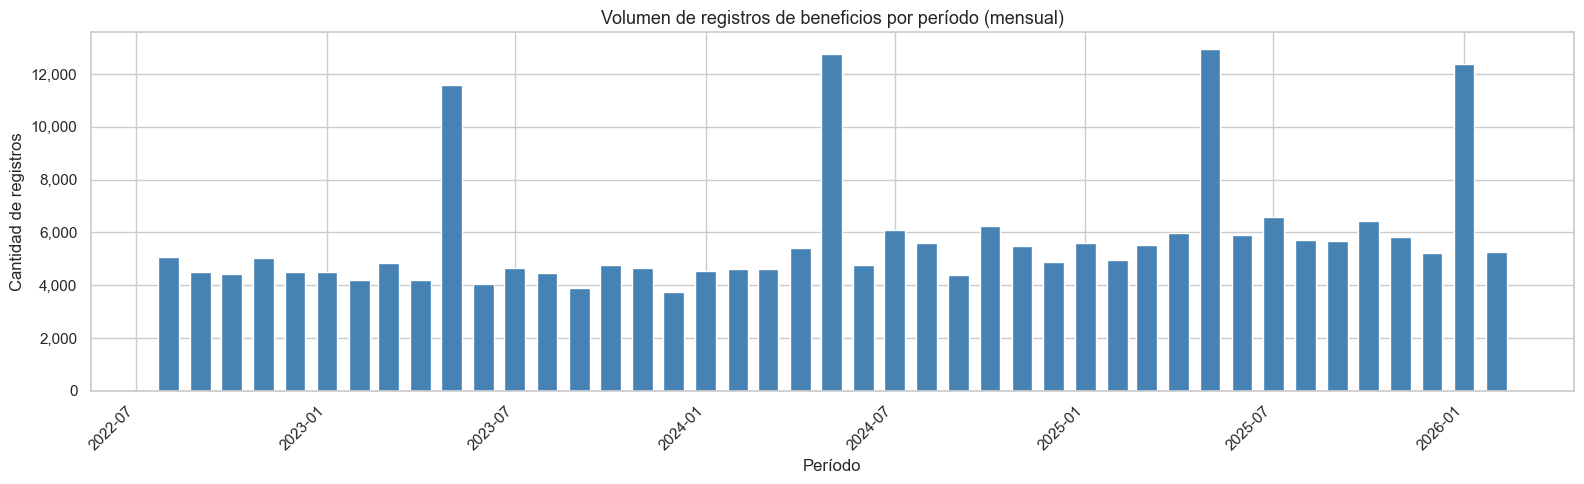


Volumen mensual detallado:


,Registros
FECHA_PERIODO,
2022-08-01,5072
2022-09-01,4504
2022-10-01,4435
2022-11-01,5023
2022-12-01,4504
2023-01-01,4494
2023-02-01,4205
2023-03-01,4838
2023-04-01,4191


In [14]:
# Volumen mensual de registros
vol_mensual = df.groupby('FECHA_PERIODO').size().reset_index(name='Registros')

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(vol_mensual['FECHA_PERIODO'], vol_mensual['Registros'], color='steelblue', width=20)
ax.set_title('Volumen de registros de beneficios por período (mensual)', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Cantidad de registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nVolumen mensual detallado:')
display(vol_mensual.set_index('FECHA_PERIODO').sort_index())

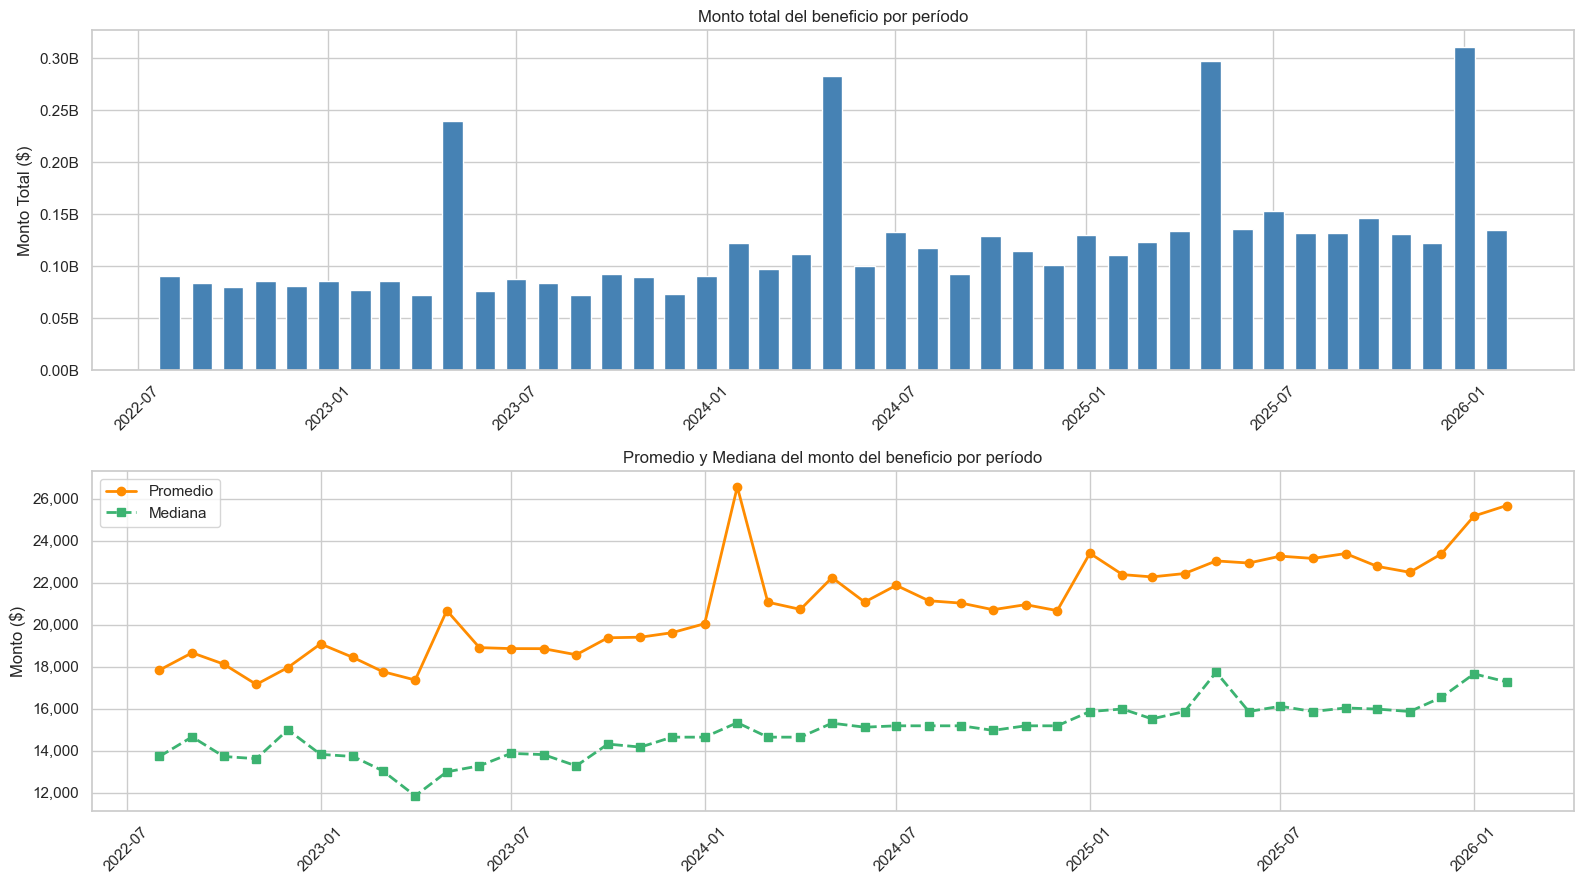

In [15]:
# Monto total y promedio del beneficio por período
monto_mensual = df.groupby('FECHA_PERIODO')['Monto_Beneficio'].agg(['sum', 'mean', 'median']).reset_index()
monto_mensual.columns = ['FECHA_PERIODO', 'Total', 'Promedio', 'Mediana']

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Total mensual
axes[0].bar(monto_mensual['FECHA_PERIODO'], monto_mensual['Total'], color='steelblue', width=20)
axes[0].set_title('Monto total del beneficio por período', fontsize=12)
axes[0].set_ylabel('Monto Total ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.2f}B'))
axes[0].tick_params(axis='x', rotation=45)

# Promedio y mediana mensual
axes[1].plot(monto_mensual['FECHA_PERIODO'], monto_mensual['Promedio'],
             marker='o', label='Promedio', color='darkorange', linewidth=2)
axes[1].plot(monto_mensual['FECHA_PERIODO'], monto_mensual['Mediana'],
             marker='s', label='Mediana', color='mediumseagreen', linewidth=2, linestyle='--')
axes[1].set_title('Promedio y Mediana del monto del beneficio por período', fontsize=12)
axes[1].set_ylabel('Monto ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
# Volumen anual de registros y monto
anual = df.groupby('ANIO').agg(
    Registros=('Monto_Beneficio', 'count'),
    Afiliados_Unicos=('ID_AFI', 'nunique'),
    Monto_Total=('Monto_Beneficio', 'sum'),
    Monto_Promedio=('Monto_Beneficio', 'mean'),
    Monto_Mediana=('Monto_Beneficio', 'median')
).reset_index()

print('=== Resumen Anual ===')
display(anual.style.format({
    'Registros': '{:,.0f}',
    'Afiliados_Unicos': '{:,.0f}',
    'Monto_Total': '{:,.0f}',
    'Monto_Promedio': '{:,.2f}',
    'Monto_Mediana': '{:,.2f}'
}))

=== Resumen Anual ===


,ANIO,Registros,Afiliados_Unicos,Monto_Total,Monto_Promedio,Monto_Mediana
0,2022,"23,538","15,658","422,055,566","17,930.82","13,905.00"
1,2023,"59,534","31,788","1,138,521,532","19,123.89","13,727.50"
2,2024,"69,361","37,351","1,495,622,910","21,562.88","15,190.00"
3,2025,"76,276","40,575","1,748,600,827","22,924.65","15,910.00"
4,2026,"17,621","9,226","446,174,078","25,320.59","17,478.00"


## 9. Análisis de Monto del Beneficio — Distribución

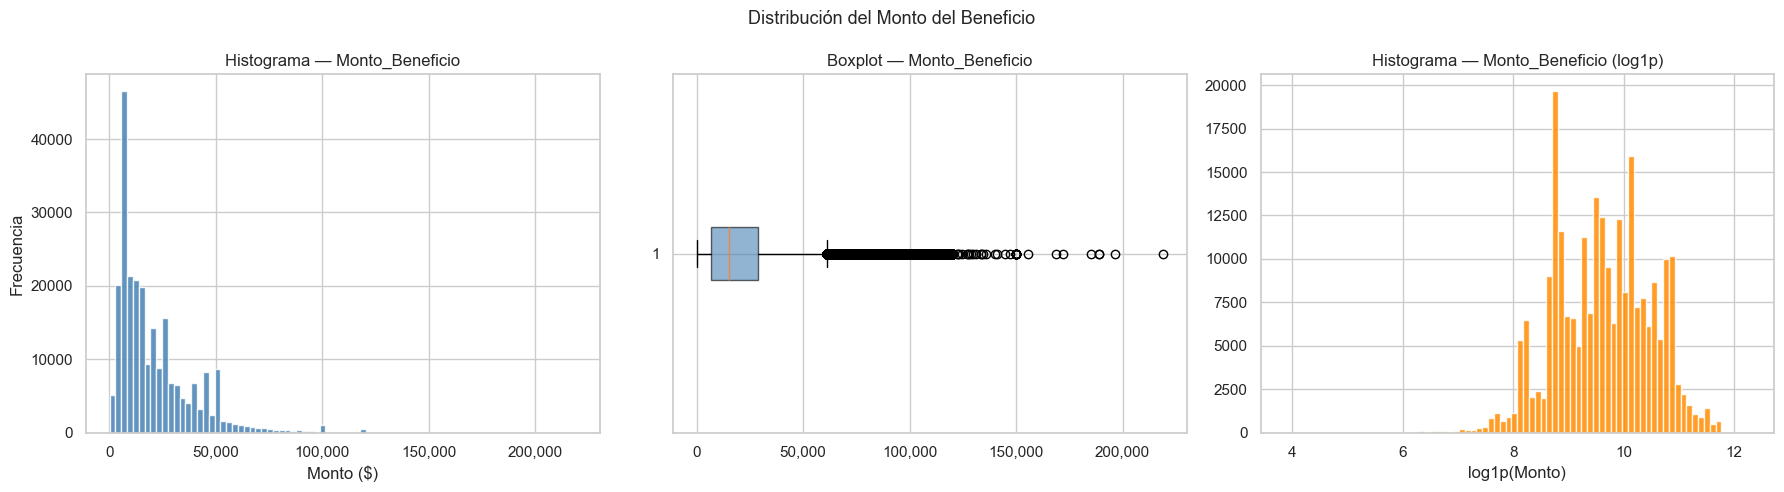

Estadísticas descriptivas de Monto_Beneficio:
count   246,330.0000
mean     21,316.8307
std      18,686.3967
min          46.0000
25%       6,940.0000
50%      15,094.5000
75%      28,566.5000
max     219,206.0000


In [17]:
monto = df['Monto_Beneficio'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(monto, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Histograma — Monto_Beneficio')
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Boxplot
axes[1].boxplot(monto, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot — Monto_Beneficio')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Histograma en escala log
axes[2].hist(np.log1p(monto), bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[2].set_title('Histograma — Monto_Beneficio (log1p)')
axes[2].set_xlabel('log1p(Monto)')

plt.suptitle('Distribución del Monto del Beneficio', fontsize=13)
plt.tight_layout()
plt.show()

print('Estadísticas descriptivas de Monto_Beneficio:')
print(monto.describe().to_string())

In [18]:
# Percentiles detallados del monto
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9]
pct_df = pd.DataFrame({
    'Percentil (%)': percentiles,
    'Monto_Beneficio ($)': [monto.quantile(p/100) for p in percentiles]
})
print('=== Percentiles del Monto_Beneficio ===')
display(pct_df.style.format({'Percentil (%)': '{:.1f}', 'Monto_Beneficio ($)': '{:,.2f}'}))

=== Percentiles del Monto_Beneficio ===


,Percentil (%),Monto_Beneficio ($)
0,1.0,"1,986.00"
1,5.0,"3,590.00"
2,10.0,"5,355.90"
3,25.0,"6,940.00"
4,50.0,"15,094.50"
5,75.0,"28,566.50"
6,90.0,"46,206.00"
7,95.0,"53,641.55"
8,99.0,"97,047.85"
9,99.9,"120,000.00"


## 10. Análisis por Tipo de Beneficio

Valores únicos de Tipo_Beneficio: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(10)]
Total de tipos distintos: 7


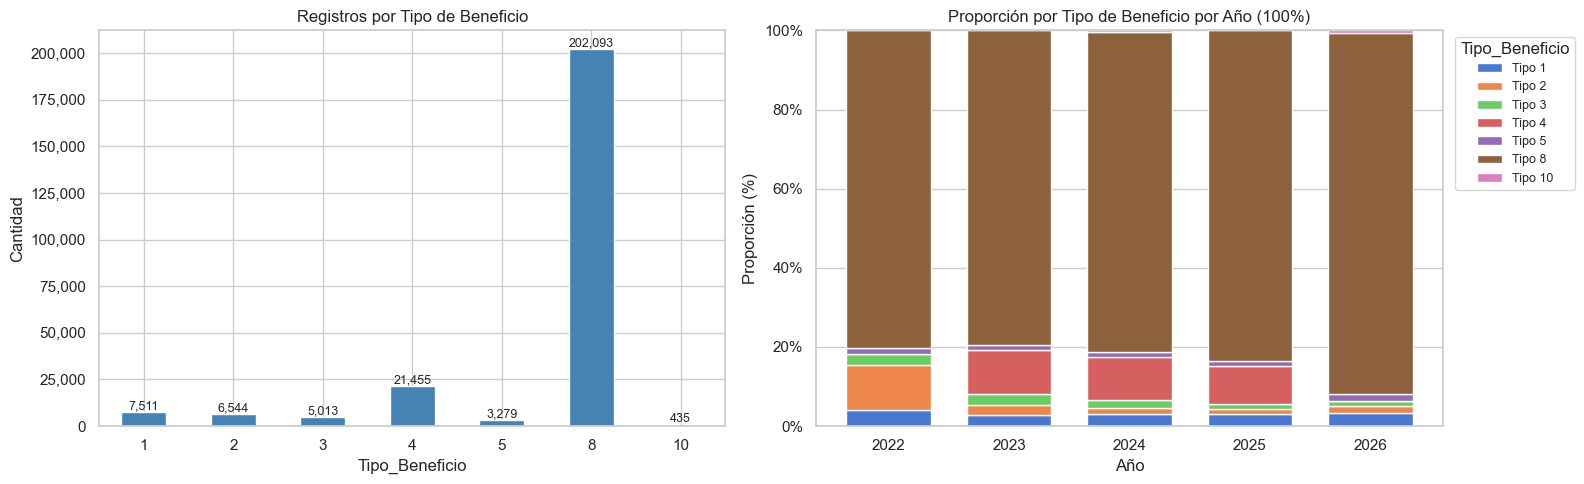

In [19]:
print(f'Valores únicos de Tipo_Beneficio: {sorted(df["Tipo_Beneficio"].unique())}')
print(f'Total de tipos distintos: {df["Tipo_Beneficio"].nunique()}')

tipo_ben = df['Tipo_Beneficio'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras de recuento por tipo
tipo_ben.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Registros por Tipo de Beneficio')
axes[0].set_xlabel('Tipo_Beneficio')
axes[0].set_ylabel('Cantidad')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

# Barras apiladas al 100% por año — reemplaza el gráfico de torta
prop_anio = df.groupby(['ANIO', 'Tipo_Beneficio']).size().unstack('Tipo_Beneficio').fillna(0)
prop_anio_pct = prop_anio.div(prop_anio.sum(axis=1), axis=0) * 100
colores = sns.color_palette('muted', len(prop_anio_pct.columns))
prop_anio_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   color=colores, edgecolor='white', width=0.7)
axes[1].set_title('Proporción por Tipo de Beneficio por Año (100%)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Proporción (%)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].legend(
    title='Tipo_Beneficio',
    labels=[f'Tipo {int(t)}' for t in prop_anio_pct.columns],
    bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9
)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [20]:
# Monto del beneficio por tipo
monto_por_tipo = df.groupby('Tipo_Beneficio')['Monto_Beneficio'].agg(
    Registros='count',
    Total='sum',
    Promedio='mean',
    Mediana='median',
    Minimo='min',
    Maximo='max'
).reset_index()

print('=== Monto del Beneficio por Tipo ===')
display(monto_por_tipo.style.format({
    'Registros': '{:,.0f}',
    'Total': '{:,.0f}',
    'Promedio': '{:,.2f}',
    'Mediana': '{:,.2f}',
    'Minimo': '{:,.0f}',
    'Maximo': '{:,.0f}'
}))

=== Monto del Beneficio por Tipo ===


,Tipo_Beneficio,Registros,Total,Promedio,Mediana,Minimo,Maximo
0,1,"7,511","425,322,374","56,626.60","50,000.00",469,"150,000"
1,2,"6,544","137,985,000","21,085.73","25,000.00","15,000","75,000"
2,3,"5,013","125,325,000","25,000.00","25,000.00","25,000","25,000"
3,4,"21,455","495,980,000","23,117.22","20,000.00","11,000","50,000"
4,5,"3,279","131,870,000","40,216.53","40,000.00","25,000","50,000"
5,8,"202,093","3,882,292,539","19,210.43","13,520.00",46,"219,206"
6,10,435,"52,200,000","120,000.00","120,000.00","120,000","120,000"


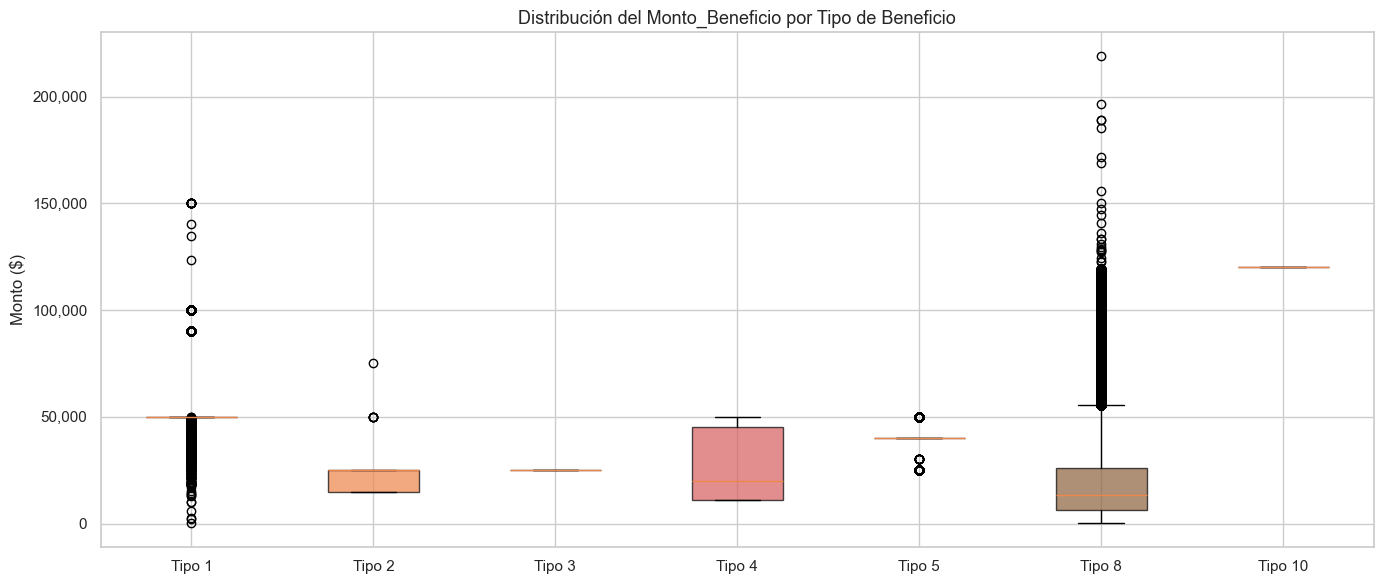

In [21]:
# Boxplot del monto por tipo de beneficio
fig, ax = plt.subplots(figsize=(14, 6))
tipos_ordenados = sorted(df['Tipo_Beneficio'].unique())
grupos = [df.loc[df['Tipo_Beneficio'] == t, 'Monto_Beneficio'].dropna() for t in tipos_ordenados]
bp = ax.boxplot(grupos, labels=[f'Tipo {t}' for t in tipos_ordenados],
                patch_artist=True, showfliers=True)
colors = sns.color_palette('muted', len(tipos_ordenados))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Distribución del Monto_Beneficio por Tipo de Beneficio', fontsize=13)
ax.set_ylabel('Monto ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

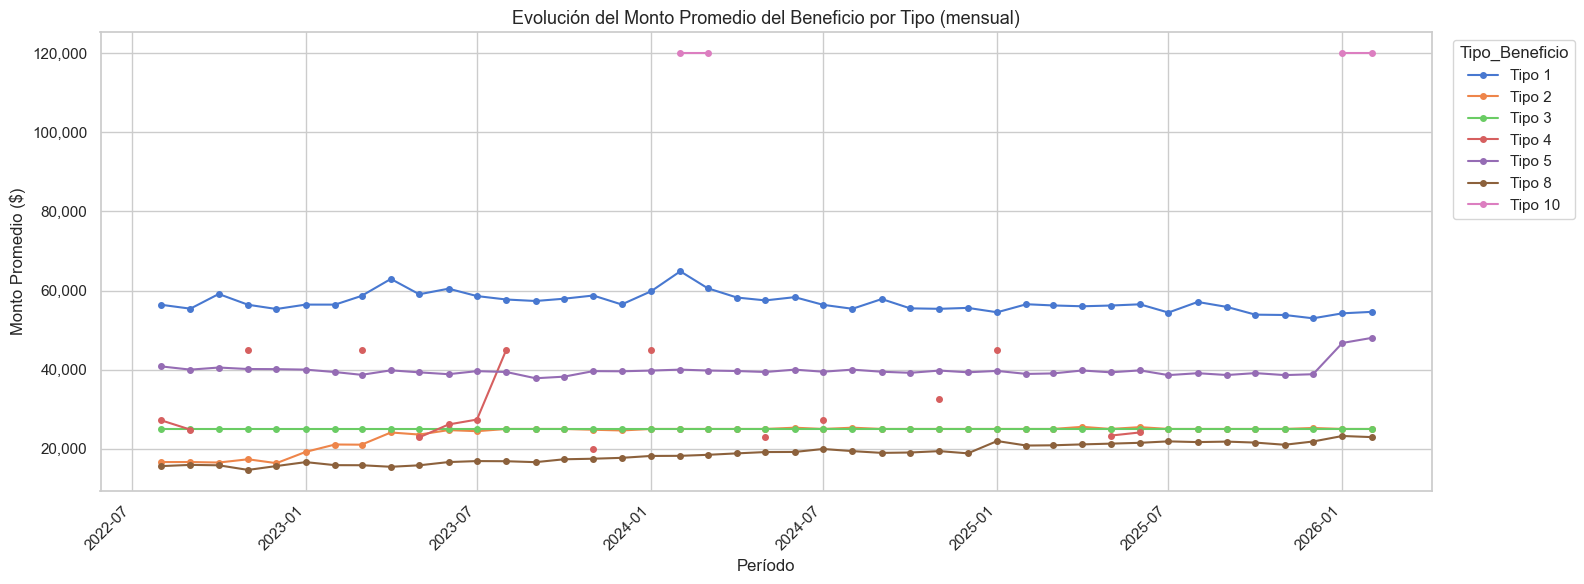

In [22]:
# Evolución temporal del monto promedio por tipo de beneficio
evol_tipo = df.groupby(['FECHA_PERIODO', 'Tipo_Beneficio'])['Monto_Beneficio'].mean().unstack('Tipo_Beneficio')

fig, ax = plt.subplots(figsize=(16, 6))
for col in evol_tipo.columns:
    ax.plot(evol_tipo.index, evol_tipo[col], marker='o', markersize=4, label=f'Tipo {col}')
ax.set_title('Evolución del Monto Promedio del Beneficio por Tipo (mensual)', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Monto Promedio ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Tipo_Beneficio', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Análisis por Tipo de Afiliado

Valores únicos de Tipo_afiliado: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11)]
Total de tipos distintos       : 10
Valores nulos                  : 5


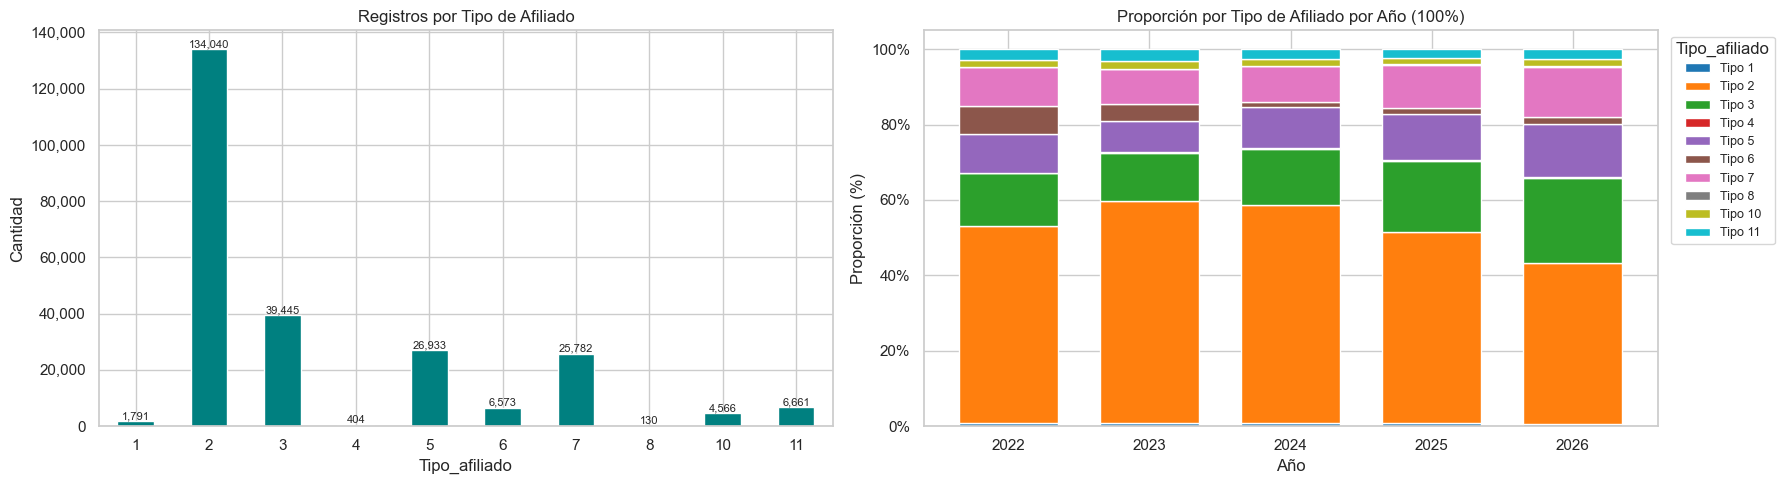

In [23]:
print(f'Valores únicos de Tipo_afiliado: {sorted(df["Tipo_afiliado"].dropna().unique())}')
print(f'Total de tipos distintos       : {df["Tipo_afiliado"].nunique()}')
print(f'Valores nulos                  : {df["Tipo_afiliado"].isnull().sum()}')

tipo_afi = df['Tipo_afiliado'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Barras de recuento por tipo de afiliado
tipo_afi.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Registros por Tipo de Afiliado')
axes[0].set_xlabel('Tipo_afiliado')
axes[0].set_ylabel('Cantidad')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Barras apiladas al 100% por año — reemplaza el gráfico de torta
prop_afi = (
    df.dropna(subset=['Tipo_afiliado'])
    .groupby(['ANIO', 'Tipo_afiliado'])
    .size()
    .unstack('Tipo_afiliado')
    .fillna(0)
)
prop_afi_pct = prop_afi.div(prop_afi.sum(axis=1), axis=0) * 100
colores = sns.color_palette('tab10', len(prop_afi_pct.columns))
prop_afi_pct.plot(kind='bar', stacked=True, ax=axes[1],
                  color=colores, edgecolor='white', width=0.7)
axes[1].set_title('Proporción por Tipo de Afiliado por Año (100%)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Proporción (%)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
axes[1].legend(
    title='Tipo_afiliado',
    labels=[f'Tipo {int(t)}' for t in prop_afi_pct.columns],
    bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9
)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

,Tipo_afiliado,Registros,Total,Promedio,Mediana
1,2,"134,040","2,679,025,201","19,986.76","13,944.00"
2,3,"39,445","864,365,964","21,913.19","15,190.00"
4,5,"26,933","648,845,670","24,091.10","15,920.00"
6,7,"25,782","593,180,348","23,007.54","15,870.00"
9,11,"6,661","161,615,762","24,262.99","16,494.00"
5,6,"6,573","137,291,212","20,887.15","15,000.00"
8,10,"4,566","122,681,956","26,868.58","19,443.00"
0,1,"1,791","32,038,917","17,888.84","11,000.00"
3,4,404,"8,824,724","21,843.38","15,870.00"
7,8,130,"2,967,390","22,826.08","15,190.00"


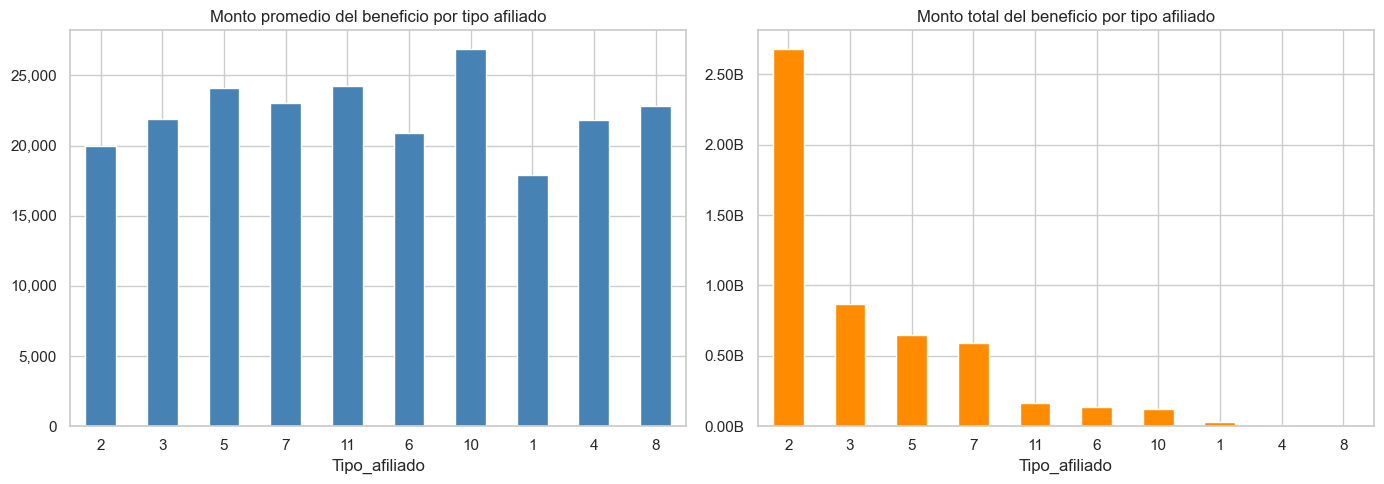

In [24]:
# Monto del beneficio por tipo de afiliado
monto_por_afi = df.groupby('Tipo_afiliado')['Monto_Beneficio'].agg(
    Registros='count',
    Total='sum',
    Promedio='mean',
    Mediana='median'
).reset_index().sort_values('Total', ascending=False)

display(monto_por_afi.style.format({
    'Registros': '{:,.0f}',
    'Total': '{:,.0f}',
    'Promedio': '{:,.2f}',
    'Mediana': '{:,.2f}'
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monto_por_afi.set_index('Tipo_afiliado')['Promedio'].plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Monto promedio del beneficio por tipo afiliado')
axes[0].set_xlabel('Tipo_afiliado')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=0)

monto_por_afi.set_index('Tipo_afiliado')['Total'].plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='white'
)
axes[1].set_title('Monto total del beneficio por tipo afiliado')
axes[1].set_xlabel('Tipo_afiliado')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:,.2f}B'))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 12. Cruce: Tipo de Afiliado × Tipo de Beneficio

In [25]:
# Tabla cruzada de frecuencias
tabla_cruce = pd.crosstab(
    df['Tipo_afiliado'],
    df['Tipo_Beneficio'],
    values=df['Monto_Beneficio'],
    aggfunc='count',
    margins=True
)
print('=== Cantidad de registros: Tipo_afiliado × Tipo_Beneficio ===')
display(tabla_cruce.style.format('{:,.0f}').background_gradient(cmap='Blues', axis=None))

=== Cantidad de registros: Tipo_afiliado × Tipo_Beneficio ===


Tipo_Beneficio,1,2,3,4,5,8,10,All
Tipo_afiliado,,,,,,,,
1,20,36,20,365,2,"1,345",3,"1,791"
2,"1,164","4,521","4,993","20,910",52,"102,060",340,"134,040"
3,"1,410",756,nan,60,"1,101","36,095",23,"39,445"
4,14,8,nan,4,1,375,2,404
5,"2,598",263,nan,12,862,"23,177",21,"26,933"
6,583,479,nan,23,252,"5,223",13,"6,573"
7,"1,282",388,nan,33,844,"23,215",20,"25,782"
8,12,3,nan,2,3,110,nan,130
10,171,33,nan,15,70,"4,274",3,"4,566"


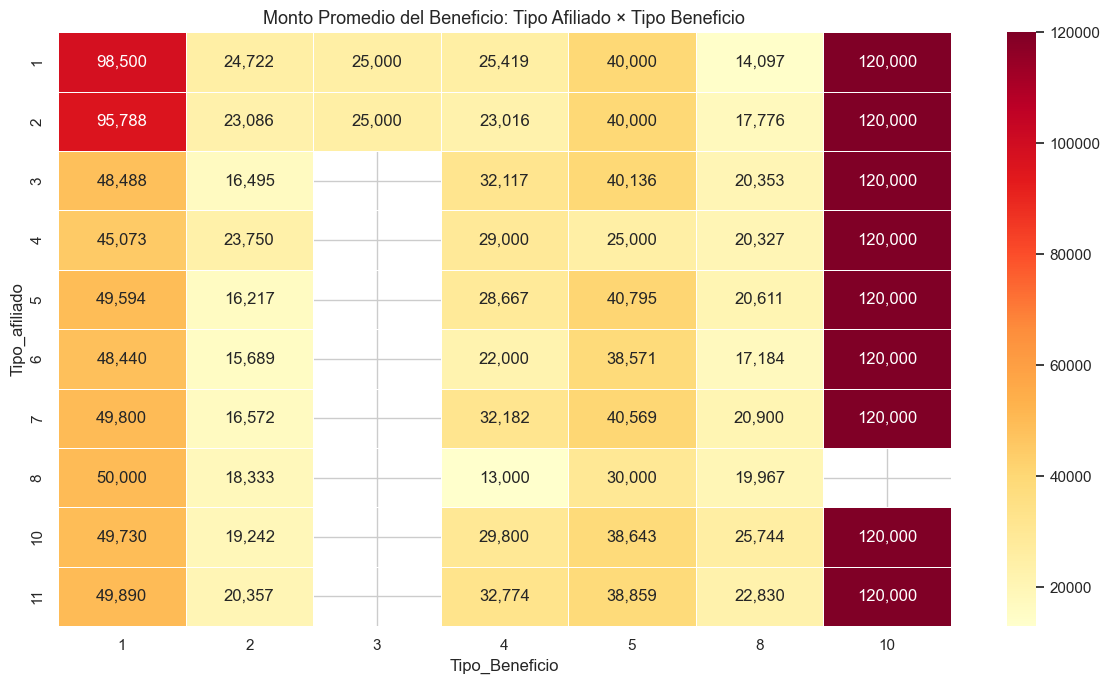

In [26]:
# Heatmap de monto promedio por tipo_afiliado y tipo_beneficio
pivot_monto = df.pivot_table(
    index='Tipo_afiliado',
    columns='Tipo_Beneficio',
    values='Monto_Beneficio',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_monto, annot=True, fmt=',.0f',
    cmap='YlOrRd', linewidths=0.5, ax=ax
)
ax.set_title('Monto Promedio del Beneficio: Tipo Afiliado × Tipo Beneficio', fontsize=13)
ax.set_xlabel('Tipo_Beneficio')
ax.set_ylabel('Tipo_afiliado')
plt.tight_layout()
plt.show()

## 13. Análisis de la Fecha de Otorgamiento del Beneficio

In [27]:
# Diferencia entre fecha de otorgamiento y fin del período
df['FECHA_FIN_PERIODO'] = df['FECHA_PERIODO'] + pd.offsets.MonthEnd(0)
df['DIAS_DESDE_PERIODO'] = (df['FECHA_OTORG'] - df['FECHA_PERIODO']).dt.days

print('Diferencia en días entre fecha de otorgamiento y inicio del período:')
print(df['DIAS_DESDE_PERIODO'].describe().to_string())
print(f'\nRegistros con fecha otorgamiento fuera del período declarado: '
      f"{((df['DIAS_DESDE_PERIODO'] < 0) | (df['DIAS_DESDE_PERIODO'] > 31)).sum():,}")

Diferencia en días entre fecha de otorgamiento y inicio del período:
count   246,330.0000
mean         16.0297
std           9.2456
min           0.0000
25%           8.0000
50%          16.0000
75%          25.0000
max          30.0000

Registros con fecha otorgamiento fuera del período declarado: 0


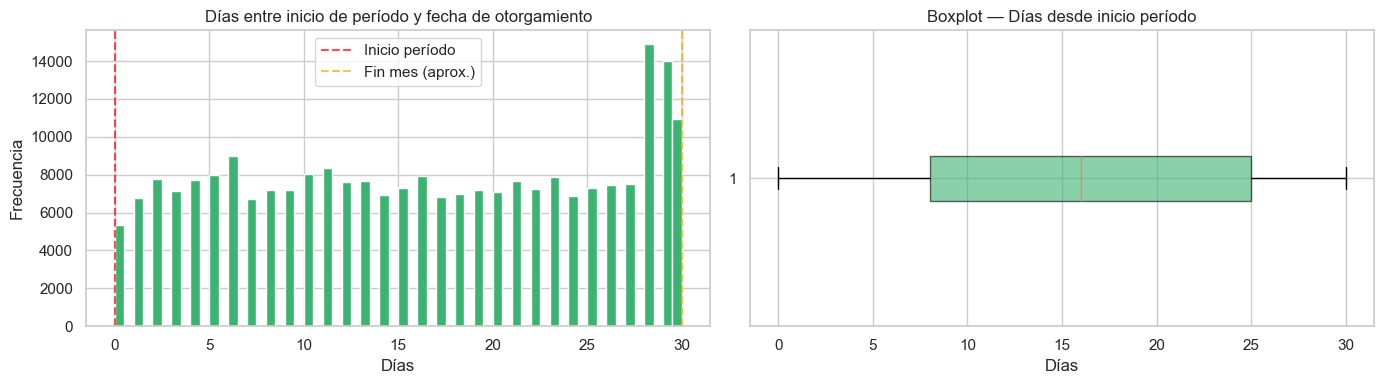

In [28]:
dias_validos = df['DIAS_DESDE_PERIODO'].dropna()
dias_validos = dias_validos[(dias_validos >= -30) & (dias_validos <= 60)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dias_validos, bins=60, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Días entre inicio de período y fecha de otorgamiento')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Inicio período')
axes[0].axvline(30, color='orange', linestyle='--', alpha=0.7, label='Fin mes (aprox.)')
axes[0].legend()

axes[1].boxplot(dias_validos, vert=False, patch_artist=True,
                boxprops=dict(facecolor='mediumseagreen', alpha=0.6))
axes[1].set_title('Boxplot — Días desde inicio período')
axes[1].set_xlabel('Días')

plt.tight_layout()
plt.show()

## 14. Análisis de la Versión (Timestamp de Carga)

=== Campo Version — Estadísticas ===
Versiones únicas   : 42
Versión más antigua: 2022-10-20 10:53:00
Versión más reciente: 2026-03-17 11:16:00


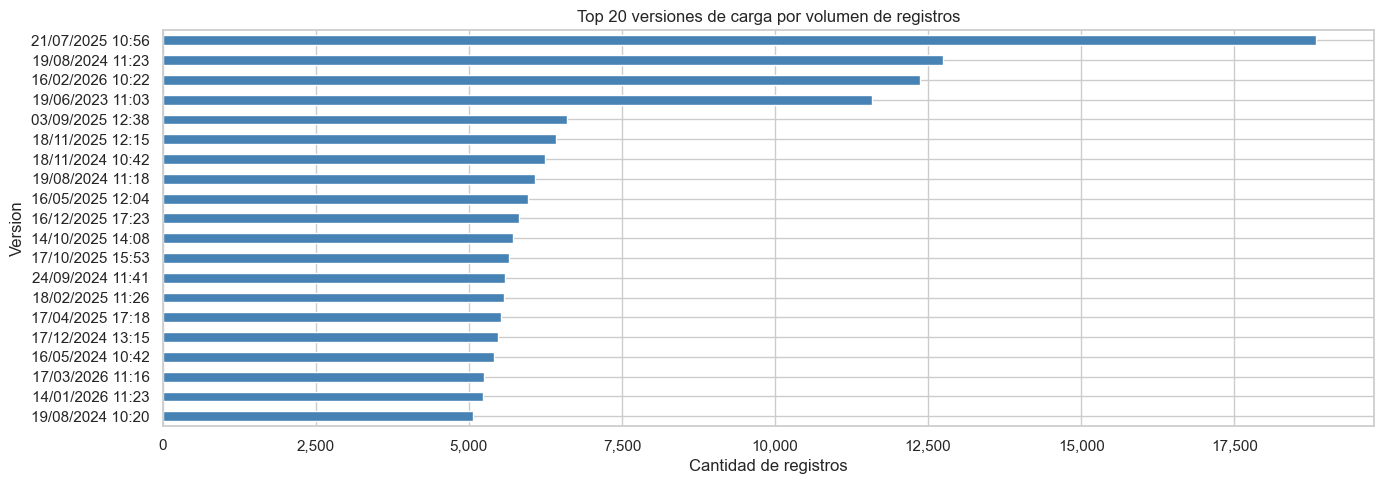

In [29]:
print('=== Campo Version — Estadísticas ===')
print(f'Versiones únicas   : {df["Version"].nunique():,}')
print(f'Versión más antigua: {df["Version_DT"].min()}')
print(f'Versión más reciente: {df["Version_DT"].max()}')

# Cantidad de registros por versión de carga
version_vol = df['Version'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 5))
version_vol.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 versiones de carga por volumen de registros', fontsize=12)
ax.set_xlabel('Cantidad de registros')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 15. Análisis de Afiliados Pseudonimizados

Afiliados únicos (pseudonimizados): 85,459
Total de registros                : 246,330
Promedio de registros por afiliado: 2.88

Distribución de registros por afiliado:
count   85,459.0000
mean         2.8824
std          3.5375
min          1.0000
25%          1.0000
50%          2.0000
75%          3.0000
max         88.0000


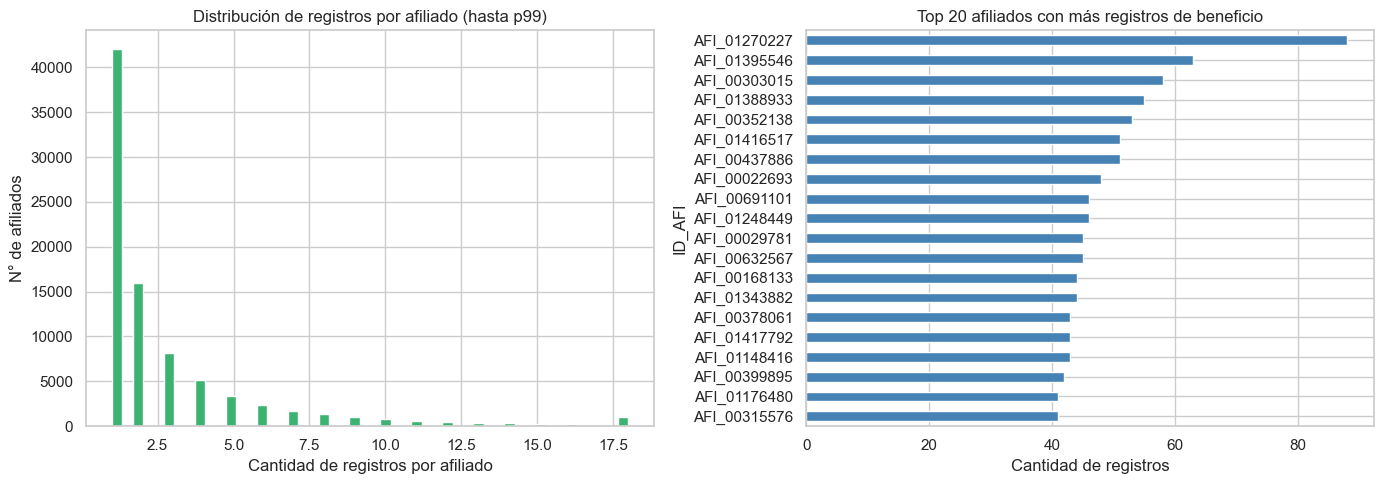

In [30]:
n_afiliados = df['ID_AFI'].nunique()
print(f'Afiliados únicos (pseudonimizados): {n_afiliados:,}')
print(f'Total de registros                : {len(df):,}')
print(f'Promedio de registros por afiliado: {len(df)/n_afiliados:.2f}')

recuento_afi = df['ID_AFI'].value_counts()
print(f'\nDistribución de registros por afiliado:')
print(recuento_afi.describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

recuento_afi.clip(upper=recuento_afi.quantile(0.99)).hist(
    bins=50, ax=axes[0], color='mediumseagreen', edgecolor='white'
)
axes[0].set_title('Distribución de registros por afiliado (hasta p99)')
axes[0].set_xlabel('Cantidad de registros por afiliado')
axes[0].set_ylabel('N° de afiliados')

recuento_afi.head(20).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Top 20 afiliados con más registros de beneficio')
axes[1].set_xlabel('Cantidad de registros')

plt.tight_layout()
plt.show()

=== Distribución del Monto Total por Afiliado ===
count    85,459.0000
mean     61,444.3758
std      63,519.1470
min         255.0000
25%      22,680.0000
50%      42,704.0000
75%      78,524.5000
max     833,215.0000


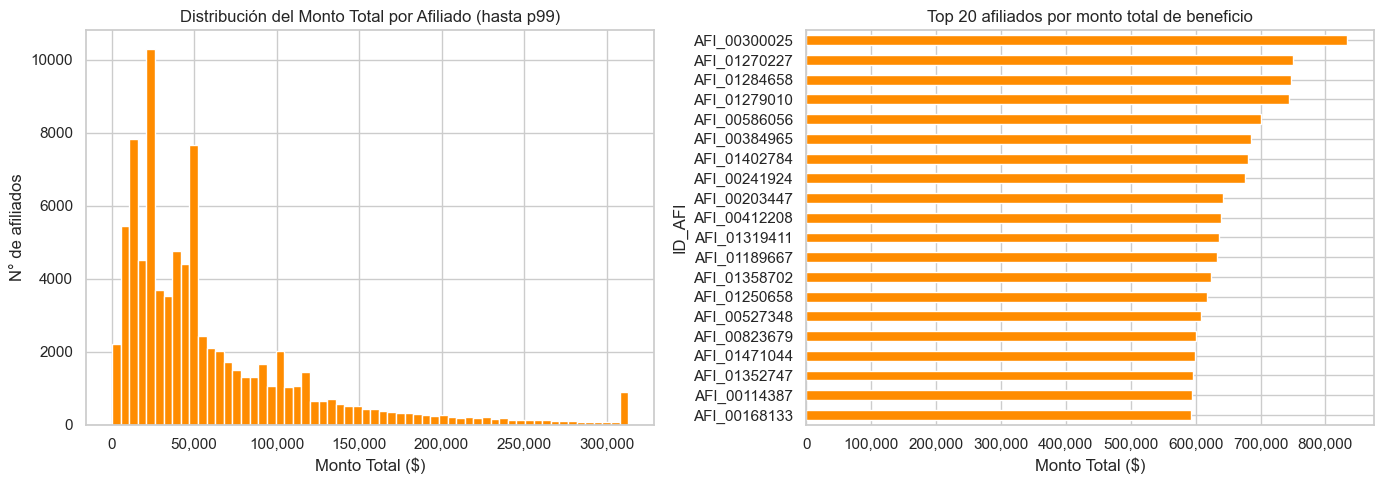

In [31]:
# Monto total recibido por afiliado
monto_afi = df.groupby('ID_AFI')['Monto_Beneficio'].agg(['sum', 'count', 'mean']).reset_index()
monto_afi.columns = ['ID_AFI', 'Monto_Total', 'N_Registros', 'Monto_Promedio']

print('=== Distribución del Monto Total por Afiliado ===')
print(monto_afi['Monto_Total'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monto_afi['Monto_Total'].clip(
    upper=monto_afi['Monto_Total'].quantile(0.99)
).hist(bins=60, ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Distribución del Monto Total por Afiliado (hasta p99)')
axes[0].set_xlabel('Monto Total ($)')
axes[0].set_ylabel('N° de afiliados')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

monto_afi.nlargest(20, 'Monto_Total').sort_values('Monto_Total').plot(
    kind='barh', x='ID_AFI', y='Monto_Total',
    ax=axes[1], color='darkorange', edgecolor='white', legend=False
)
axes[1].set_title('Top 20 afiliados por monto total de beneficio')
axes[1].set_xlabel('Monto Total ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

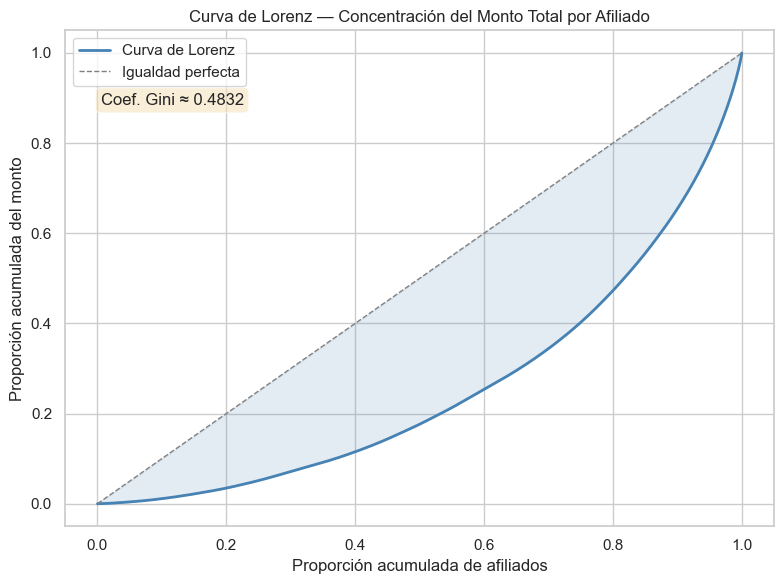

Coeficiente de Gini aproximado: 0.4832


In [32]:
# Concentración: curva de Lorenz aproximada
montos_sorted = np.sort(monto_afi['Monto_Total'].values)
cumsum = np.cumsum(montos_sorted)
lorenz_x = np.linspace(0, 1, len(montos_sorted))
lorenz_y = cumsum / cumsum[-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(lorenz_x, lorenz_y, color='steelblue', linewidth=2, label='Curva de Lorenz')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Igualdad perfecta')
ax.fill_between(lorenz_x, lorenz_y, lorenz_x, alpha=0.15, color='steelblue')
ax.set_title('Curva de Lorenz — Concentración del Monto Total por Afiliado', fontsize=12)
ax.set_xlabel('Proporción acumulada de afiliados')
ax.set_ylabel('Proporción acumulada del monto')
ax.legend()

# Coeficiente de Gini aproximado
n = len(montos_sorted)
gini = (2 * np.sum(np.arange(1, n+1) * montos_sorted) / (n * cumsum[-1])) - (n + 1) / n
ax.text(0.05, 0.85, f'Coef. Gini ≈ {gini:.4f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
print(f'Coeficiente de Gini aproximado: {gini:.4f}')

## 16. Detección de Outliers — Monto del Beneficio

In [33]:
def detectar_outliers_iqr(serie, nombre):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    return {
        'Columna': nombre,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Límite inferior': lower,
        'Límite superior': upper,
        'N° outliers': len(outliers),
        '% outliers': round(len(outliers) / len(serie) * 100, 2)
    }

resumen_outliers = pd.DataFrame([
    detectar_outliers_iqr(df['Monto_Beneficio'].dropna(), 'Monto_Beneficio')
])
print('=== Detección de Outliers (método IQR) ===')
display(resumen_outliers.set_index('Columna').style.format('{:,.2f}'))

=== Detección de Outliers (método IQR) ===


,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
Columna,,,,,,,
Monto_Beneficio,"6,940.00","28,566.50","21,626.50","-25,499.75","61,006.25","8,729.00",3.54


In [34]:
# Outliers por tipo de beneficio
print('=== Outliers de Monto_Beneficio por Tipo_Beneficio ===')
resultados = []
for tipo in sorted(df['Tipo_Beneficio'].unique()):
    serie = df.loc[df['Tipo_Beneficio'] == tipo, 'Monto_Beneficio'].dropna()
    res = detectar_outliers_iqr(serie, f'Tipo {tipo}')
    resultados.append(res)
df_outliers_tipo = pd.DataFrame(resultados).set_index('Columna')
display(df_outliers_tipo.style.format('{:,.2f}'))

=== Outliers de Monto_Beneficio por Tipo_Beneficio ===


,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
Columna,,,,,,,
Tipo 1,"50,000.00","50,000.00",0.00,"50,000.00","50,000.00","1,404.00",18.69
Tipo 2,"15,000.00","25,000.00","10,000.00",0.00,"40,000.00",6.00,0.09
Tipo 3,"25,000.00","25,000.00",0.00,"25,000.00","25,000.00",0.00,0.00
Tipo 4,"11,000.00","45,000.00","34,000.00","-40,000.00","96,000.00",0.00,0.00
Tipo 5,"40,000.00","40,000.00",0.00,"40,000.00","40,000.00",442.00,13.48
Tipo 8,"6,540.00","26,083.00","19,543.00","-22,774.50","55,397.50","9,795.00",4.85
Tipo 10,"120,000.00","120,000.00",0.00,"120,000.00","120,000.00",0.00,0.00


## 17. Análisis de Correlaciones

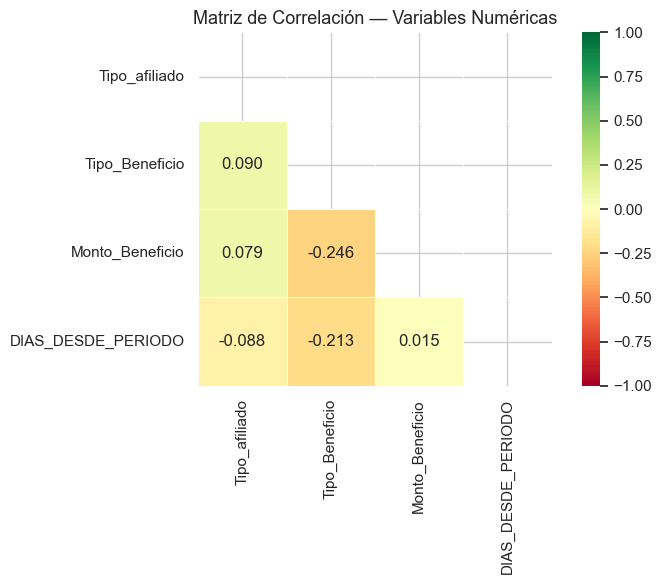

In [35]:
cols_corr = ['Tipo_afiliado', 'Tipo_Beneficio', 'Monto_Beneficio', 'DIAS_DESDE_PERIODO']
cols_corr = [c for c in cols_corr if c in df.columns]

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Matriz de Correlación — Variables Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

## 18. Resumen Ejecutivo

In [36]:
print('=' * 65)
print('   RESUMEN EJECUTIVO — EDA BENEF. MENSUAL BNF (10101)')
print('=' * 65)

print(f'\n[VOLUMEN]')
print(f'  Total registros          : {len(df):,}')
print(f'  Total columnas originales: 7')
print(f'  Rango temporal (Periodo) : {df["FECHA_PERIODO"].min().strftime("%Y-%m")} → {df["FECHA_PERIODO"].max().strftime("%Y-%m")}')
print(f'  Afiliados únicos         : {df["ID_AFI"].nunique():,}')

print(f'\n[MONTO DEL BENEFICIO]')
print(f'  Total acumulado : ${df["Monto_Beneficio"].sum():>20,.0f}')
print(f'  Promedio        : ${df["Monto_Beneficio"].mean():>20,.2f}')
print(f'  Mediana         : ${df["Monto_Beneficio"].median():>20,.2f}')
print(f'  Mínimo          : ${df["Monto_Beneficio"].min():>20,.0f}')
print(f'  Máximo          : ${df["Monto_Beneficio"].max():>20,.0f}')

print(f'\n[CALIDAD DE DATOS]')
pct_nulos_total = df[['Periodo','Version','Tipo_afiliado','Tipo_Beneficio',
                       'Monto_Beneficio','Fecha_Otorg_Beneficio','ID_AFI']].isnull().sum().sum()
total_celdas = len(df) * 7
print(f'  Tasa de nulidad global   : {pct_nulos_total/total_celdas*100:.4f}%')
print(f'  Nulos en Tipo_afiliado   : {df["Tipo_afiliado"].isnull().sum()}')
print(f'  Duplicados exactos       : {df.duplicated(subset=["Periodo","Version","Tipo_afiliado","Tipo_Beneficio","Monto_Beneficio","Fecha_Otorg_Beneficio","ID_AFI"]).sum():,}')

print(f'\n[TIPOS DE BENEFICIO]')
for tipo, cnt in df['Tipo_Beneficio'].value_counts().sort_index().items():
    pct = cnt / len(df) * 100
    print(f'  Tipo {tipo}: {cnt:>8,} registros ({pct:5.1f}%)')

print(f'\n[COBERTURA DE AFILIADOS]')
rec_afi = df['ID_AFI'].value_counts()
print(f'  Promedio beneficios/afiliado: {rec_afi.mean():.2f}')
print(f'  Mediana  beneficios/afiliado: {rec_afi.median():.2f}')
print(f'  Máximo   beneficios/afiliado: {rec_afi.max()}')
print(f'  Afiliados con 1 solo registro: {(rec_afi == 1).sum():,} ({(rec_afi==1).sum()/len(rec_afi)*100:.1f}%)')

print('\n' + '=' * 65)

   RESUMEN EJECUTIVO — EDA BENEF. MENSUAL BNF (10101)

[VOLUMEN]
  Total registros          : 246,330
  Total columnas originales: 7
  Rango temporal (Periodo) : 2022-08 → 2026-02
  Afiliados únicos         : 85,459

[MONTO DEL BENEFICIO]
  Total acumulado : $       5,250,974,913
  Promedio        : $           21,316.83
  Mediana         : $           15,094.50
  Mínimo          : $                  46
  Máximo          : $             219,206

[CALIDAD DE DATOS]
  Tasa de nulidad global   : 0.0003%
  Nulos en Tipo_afiliado   : 5
  Duplicados exactos       : 7,258

[TIPOS DE BENEFICIO]
  Tipo 1:    7,511 registros (  3.0%)
  Tipo 2:    6,544 registros (  2.7%)
  Tipo 3:    5,013 registros (  2.0%)
  Tipo 4:   21,455 registros (  8.7%)
  Tipo 5:    3,279 registros (  1.3%)
  Tipo 8:  202,093 registros ( 82.0%)
  Tipo 10:      435 registros (  0.2%)

[COBERTURA DE AFILIADOS]
  Promedio beneficios/afiliado: 2.88
  Mediana  beneficios/afiliado: 2.00
  Máximo   beneficios/afiliado: 88
  Af